# Prédiction de la survie des passagers du Titanic

## Importation des bibliothèques

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement du jeu de données Titanic

In [16]:
titanic=pd.read_csv("titanic.csv")

In [17]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Exploratory Data Analysis

### Objectifs :
- Mieux comprendre les données
- Développer une première stratégie de modélisation 
- Avoir un Recall de plus de 80% et un F1-Score de plus de 70%

### Checklist de base 

#### Analyse de forme :
- **variable target :** Survived (0, 1)
- **lignes et colonnes :** 891 observations , 12 variables
- **types de variables :** 7 variables quantitatives et 5 variable qualitative
- **analyse des valeurs manquantes :** plusieurs valeurs manquantes dans les variables Age (20%) et Cabin(70%), absence de valeurs manquantes sur les autres colonnes.

#### Analyse de fond
- **visualisation de la target :** 62% de décès
- **signification des variables :** les variables Age et Fare ne sont ni standardisées, ni normalisées et certaines présentent une légère asymétrie (beaucoup plus marquée avec la variable Fare)
- **relation varibles explicatives / target :** 
    - les deux variables numériques Age et Fare sont significatives
    - les variable Sex, Pclass, Embarked montrent une relation statistiquement significative avec la survie, ce qui confirme qu’elles sont pertinentes pour la régression logistique.
- **relation entre variables explicatives :** on remarque une absence de corrélation linéaire entre Age et Fare

#### Analyse du modèle

- **Sélection des variables :** La sélection stepwise a permis de conserver les variables les plus pertinentes : Sex, Pclass, Embarked_S et les tranches d'âge. Les variables moins informatives, comme Fare et Embarked_Q, ont été supprimées.
- **Performance globale :** Après optimisation du seuil pour maximiser le recall de la classe 1 (survivants), le modèle atteint un **accuracy de 0,78-0,80**, avec un **recall amélioré pour la classe 1**.
- **Courbe ROC et AUC :** L’AUC = 0,864 montre que le modèle **sépare très bien les survivants des non-survivants**, avec une probabilité de 86,4% de donner une meilleure prédiction de survie à un survivant qu’à un non-survivant choisi au hasard.
- **Interprétation pratique :** Le modèle optimisé est donc fiable pour identifier les survivants, tout en restant robuste et pertinent sur l’ensemble des passagers, même avant d’appliquer un seuil spécifique.


#### Analyse de forme 

In [18]:
# Copie de la base 
df = titanic.copy()

In [19]:
df['Survived'].unique()

array([0, 1])

In [20]:
# Dimension 
df.shape

(891, 12)

In [21]:
# Vérification des types de colonnes
df.dtypes.value_counts()

int64      5
object     5
float64    2
Name: count, dtype: int64

In [22]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

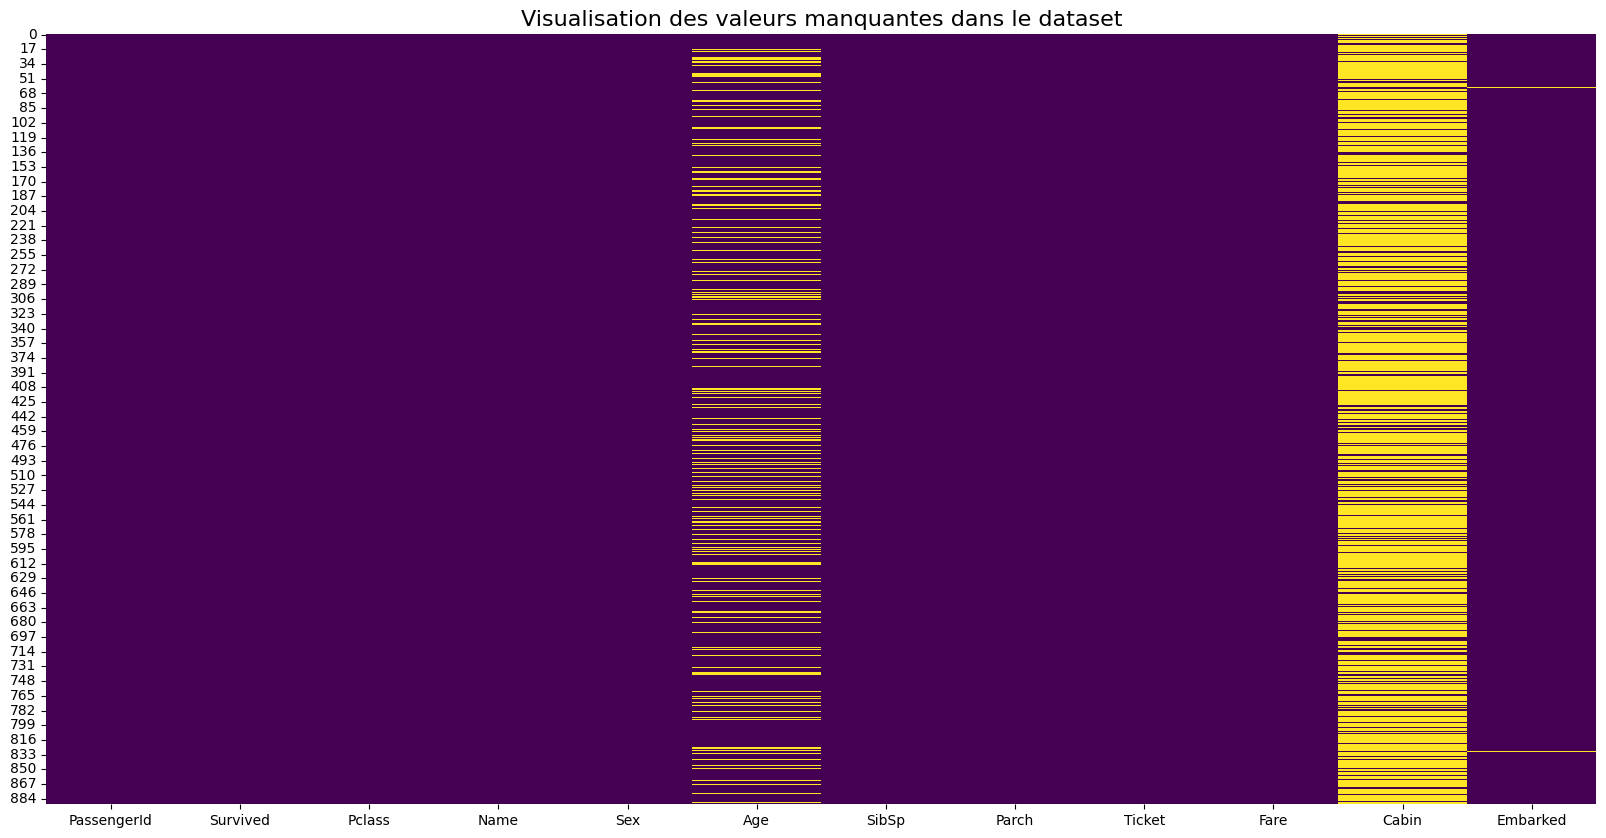

In [23]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Visualisation des valeurs manquantes dans le dataset', fontsize=16)  
plt.show()

In [24]:
# Pourcentage des valeurs manquantes par colonne
(df.isnull().sum()/df.shape[0]  * 100).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

#### **Analyse de fond**

**Examen de la variable target**

In [25]:
df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

**Visualisation de la varibale target**

<Axes: title={'center': 'Répartition des cas (0 = Mort, B = Survivant)'}, ylabel='count'>

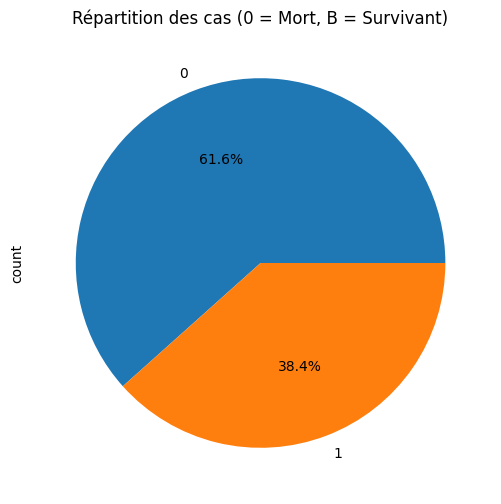

In [26]:
df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), title='Répartition des cas (0 = Mort, B = Survivant)')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Selection des variables**

In [28]:
df = df[['Survived', 'Sex', 'Age', 'Pclass', 'Fare', 'Embarked']]

**Retypage**

In [29]:
# Conversion en type catégorie
df['Survived'] = df['Survived'].astype('object')
df['Pclass'] = df['Pclass'].astype('object')

**Histogramme des variables continues**

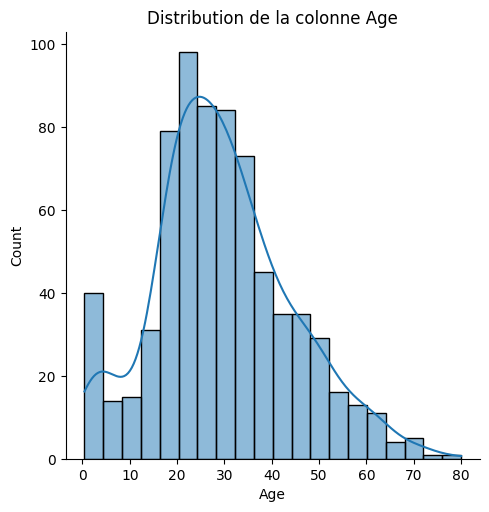

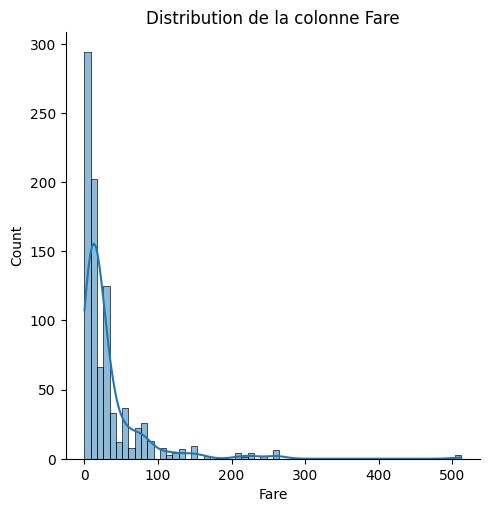

In [30]:
for col in df.select_dtypes(include=['float', 'int']).columns:
    sns.displot(df[col], kde=True)
    plt.title(f'Distribution de la colonne {col}')

**Visualisation des varibles catégorielles**

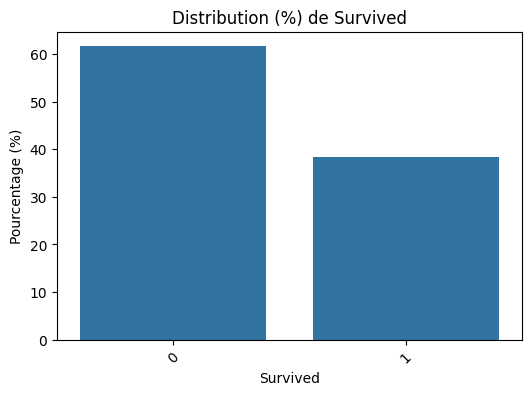

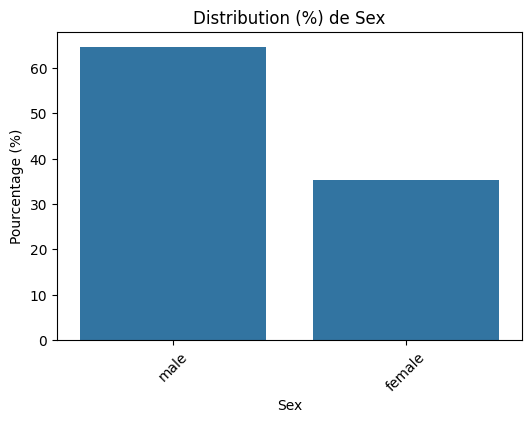

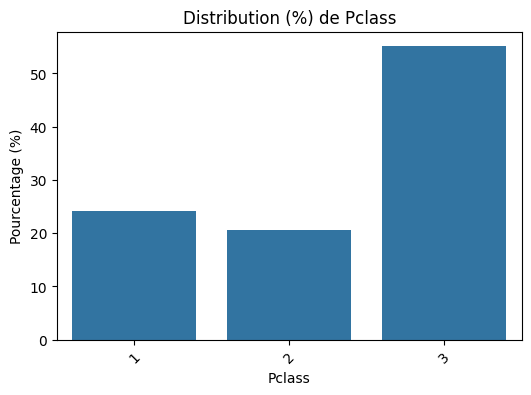

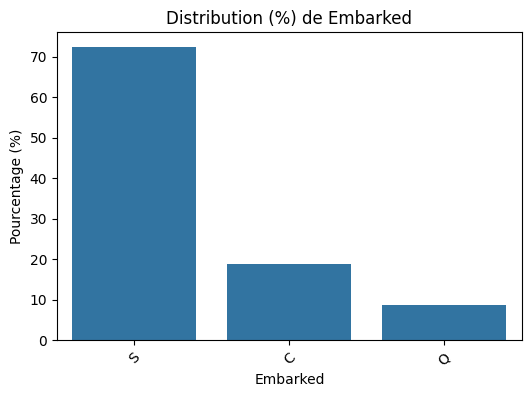

In [31]:
for col in df.select_dtypes(exclude=['float', 'int']).columns:
    freq = df[col].value_counts(normalize=True) * 100

    plt.figure(figsize=(6,4))
    sns.barplot(x=freq.index, y=freq.values)
    plt.title(f"Distribution (%) de {col}")
    plt.ylabel("Pourcentage (%)")
    plt.xticks(rotation=45)
    plt.show()

**Relation entre les variables explicatives et la variable cible**

Création de deux sous-ensembles 0 (not survived) et 1 (survived)

In [32]:
not_survived_df = df[df['Survived'] == 0]
survived_df = df[df['Survived'] == 1]

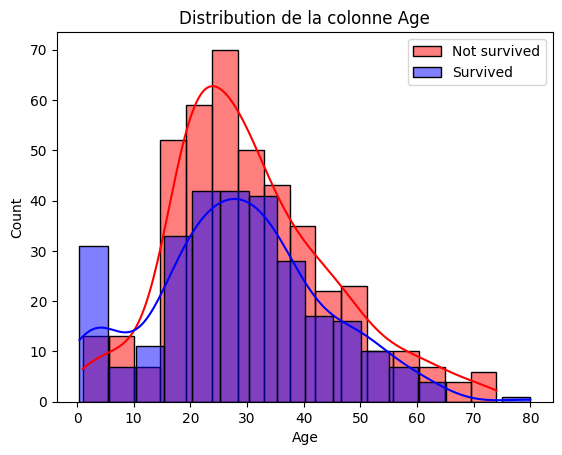

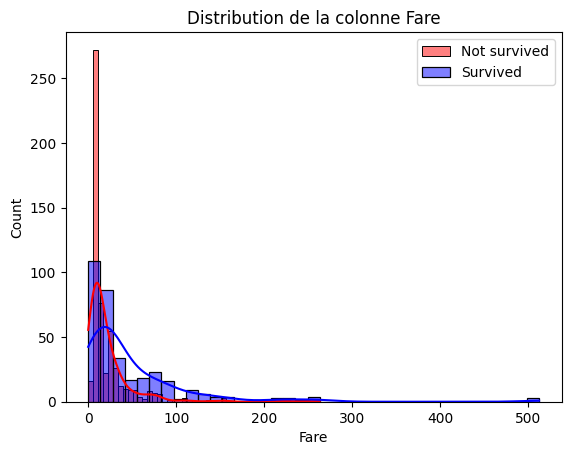

In [33]:
for col in df.select_dtypes(include=['float', 'int']).columns:
    plt.figure()
    sns.histplot(not_survived_df[col].dropna(), color='red', kde=True, label='Not survived')
    sns.histplot(survived_df[col].dropna(), color='blue', kde=True, label='Survived')
    plt.title(f'Distribution de la colonne {col}')
    plt.legend()
    plt.show()

In [34]:
from scipy.stats import ttest_ind

# Colonnes à tester
cols_to_test = ["Age", "Fare"]

for col in cols_to_test:
    # Séparer selon la variable cible
    group0 = df[df["Survived"] == 0][col].dropna()  
    group1 = df[df["Survived"] == 1][col].dropna()  
    
    # Test t de Student 
    p_value = ttest_ind(group0, group1, equal_var=False).pvalue
    
    print(f"P-value for {col}: {p_value:.5f}")


P-value for Age: 0.04119
P-value for Fare: 0.00000


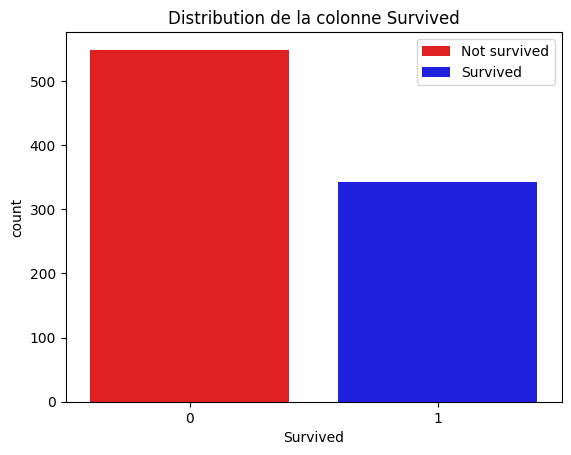

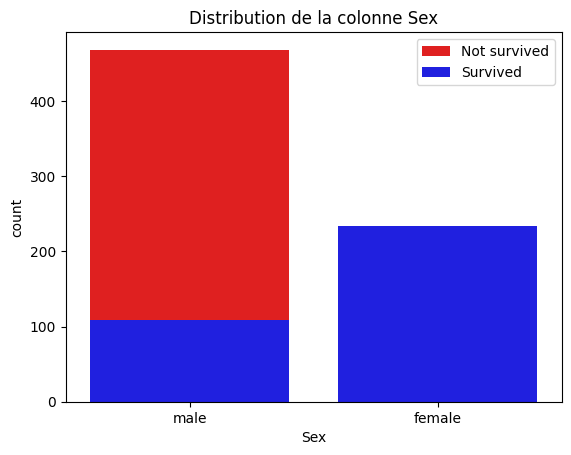

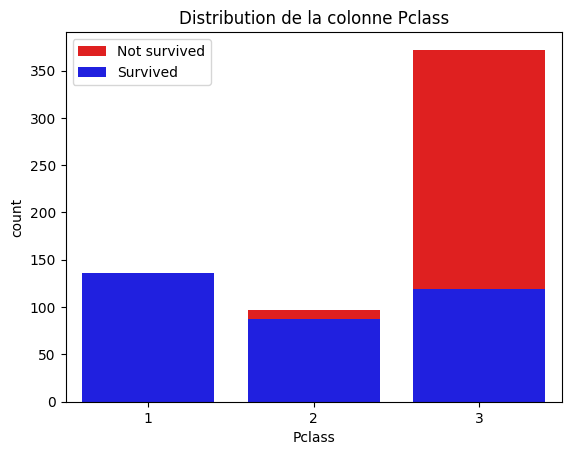

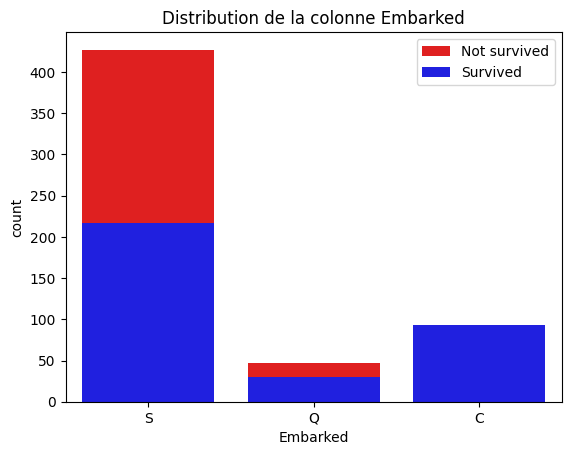

In [35]:
for col in df.select_dtypes(exclude=['float', 'int']).columns:
    plt.figure()
    sns.countplot(data=not_survived_df, x=col, color='red', label='Not survived')
    sns.countplot(data=survived_df, x=col, color='blue', label='Survived')
    plt.title(f'Distribution de la colonne {col}')
    plt.legend()
    plt.show()

In [36]:
from scipy.stats import chi2_contingency

categorical_cols = ["Sex", "Pclass", "Embarked"]  

for col in categorical_cols:
    # Créer un tableau de contingence
    contingency_table = pd.crosstab(df[col], df["Survived"])
    
    # Test du Chi2
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"P-value for {col}: {p:.5f}")

P-value for Sex: 0.00000
P-value for Pclass: 0.00000
P-value for Embarked: 0.00000


**Relation entre variables explicatives**

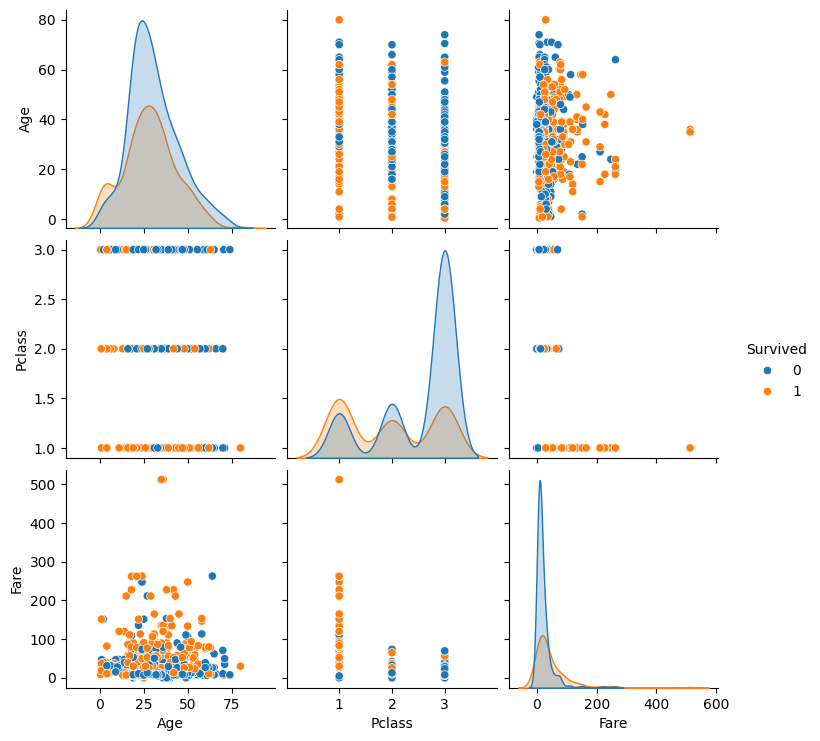

In [37]:
sns.pairplot(df, hue='Survived')

<Axes: >

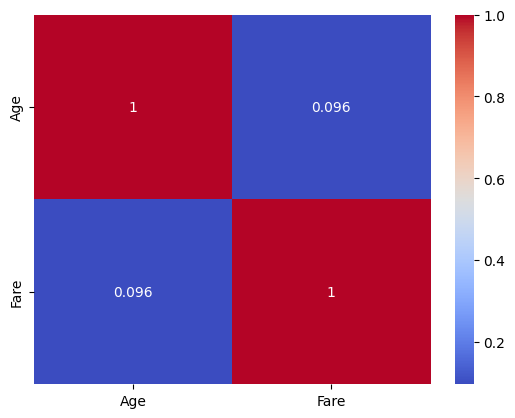

In [38]:
sns.heatmap(df[cols_to_test].corr(), annot=True, cmap='coolwarm')

**Détection des outliers**

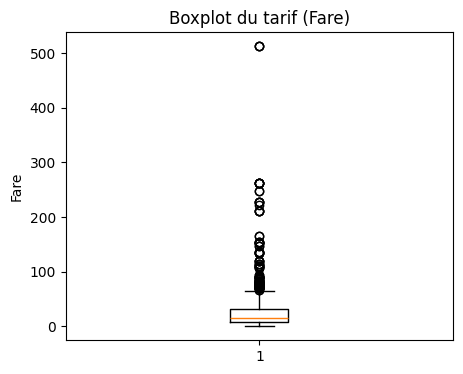

In [39]:
plt.figure(figsize=(5, 4))
plt.boxplot(df['Fare'].dropna())
plt.title("Boxplot du tarif (Fare)")
plt.ylabel("Fare")
plt.show()

***La variable Fare présente de nombreux outliers et une forte asymétrie à droite, ce qui est courant pour des variables économiques. Ces valeurs extrêmes correspondent à des passagers ayant payé des tarifs très élevés et ne constituent pas des erreurs. Au besoin, nous reviendrons pour le traitement.***


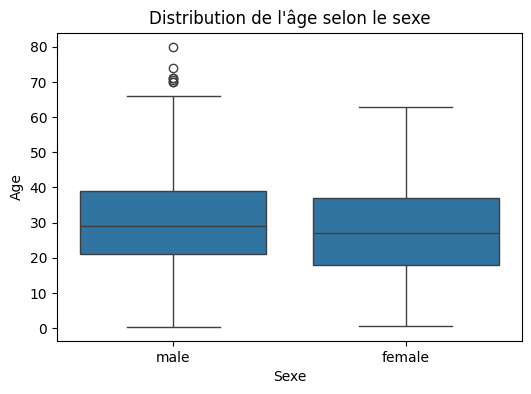

In [40]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Sex', y='Age', data=df)
plt.title("Distribution de l'âge selon le sexe")
plt.xlabel("Sexe")
plt.ylabel("Age")
plt.show()

***Les valeurs élevées de l’âge observées chez certains passagers masculins ne sont pas supprimées, car elles correspondent à des âges réalistes. De plus, l’âge sera discrétisé en tranches, l’influence des valeurs extrêmes sera limitée, rendant inutile tout traitement spécifique des outliers.***

## 2. Division de la base en Train / Test

- Les variables explicatives et la variable cible

In [41]:
X = df.drop(columns='Survived')
y = df['Survived']

In [42]:
X.head()

,Sex,Age,Pclass,Fare,Embarked
0,male,22.0,3,7.2500,S
1,female,38.0,1,71.2833,C
2,female,26.0,3,7.9250,S
3,female,35.0,1,53.1000,S
4,male,35.0,3,8.0500,S


In [43]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [44]:
y = y.astype('int64')

- Train / Test

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [47]:
print(f"Les dimensions de X_train : {X_train.shape}")
print(f"Les dimensions de X_train : {X_test.shape}")
print(f"Les dimensions de y_train : {y_train.shape}")
print(f"Les dimensions de X_train : {y_test.shape}")

Les dimensions de X_train : (623, 5)
Les dimensions de X_train : (268, 5)
Les dimensions de y_train : (623,)
Les dimensions de X_train : (268,)


## 3. Preprocessing

#### Imputation des valeurs manquantes

- pour la variable Age, nous prendrons la médiane des hommes pour les hommes et la médiane des femmes pour les femmes.

In [48]:
age_medians = X_train.groupby('Sex')['Age'].median()

- pour la variable Embarked, nous prendrons le mode.

In [49]:
embarked_mode = X_train['Embarked'].mode()[0]

- Définition d'une fonction de préprocessing

In [50]:
def processor(data, age_medians, embarked_mode):
    df = data.copy()

    df['Age'] = df['Age'].fillna(
        df['Sex'].map(age_medians)
    )

    df['Embarked'] = df['Embarked'].fillna(embarked_mode)

    df['TrancheAge'] = pd.cut(
        df['Age'],
        bins=[0, 12, 18, 35, 60, 80],
        labels=['[0,12]', '[13,18]', '[19,35]', '[36,60]', '[61,80]'],
        include_lowest=True
    )

    df.drop(columns='Age', inplace=True)

    df = pd.get_dummies(
        df,
        columns=['Sex', 'TrancheAge', 'Embarked', 'Pclass'],
        drop_first=True
    )
    
    bool_cols = df.select_dtypes('bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    return df


In [51]:
X_train_p = processor(X_train, age_medians, embarked_mode)

In [52]:
X_train_p.head()

,Fare,Sex_male,"TrancheAge_[13,18]","TrancheAge_[19,35]","TrancheAge_[36,60]","TrancheAge_[61,80]",Embarked_Q,Embarked_S,Pclass_2,Pclass_3
445,81.8583,1,0,0,0,0,0,1,0,0
650,7.8958,1,0,1,0,0,0,1,0,1
172,11.1333,0,0,0,0,0,0,1,0,1
450,27.7500,1,0,0,1,0,0,1,1,0
314,26.2500,1,0,0,1,0,0,1,1,0


- la proportion de valeurs manquantes

In [53]:
# Pourcentage des valeurs manquantes par colonne
(X_train_p.isnull().sum()/X_train_p.shape[0]  * 100).sort_values(ascending=False)

Fare                  0.0
Sex_male              0.0
TrancheAge_[13,18]    0.0
TrancheAge_[19,35]    0.0
TrancheAge_[36,60]    0.0
TrancheAge_[61,80]    0.0
Embarked_Q            0.0
Embarked_S            0.0
Pclass_2              0.0
Pclass_3              0.0
dtype: float64

## 4. Modélisation

In [54]:
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train_p, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Calcul des Odds Ratio

In [55]:
# Coefficients
coef = pd.Series(model.coef_[0], index=X_train_p.columns)

# Odds Ratio
odds_ratio = np.exp(coef)

or_table = pd.DataFrame({
    'Coefficient': coef,
    'Odds Ratio': odds_ratio
}).sort_values(by='Odds Ratio', ascending=False)

print(or_table)


                    Coefficient  Odds Ratio
Fare                   0.002534    1.002537
Embarked_Q            -0.162726    0.849824
Pclass_2              -0.190435    0.826600
Embarked_S            -0.765305    0.465192
TrancheAge_[61,80]    -0.793250    0.452372
TrancheAge_[19,35]    -0.824499    0.438455
TrancheAge_[13,18]    -1.092812    0.335272
TrancheAge_[36,60]    -1.119280    0.326515
Pclass_3              -1.509935    0.220924
Sex_male              -2.401358    0.090595


***Les chances de survie étaient fortement influencées par le sexe et la classe : les femmes et les passagers de première classe avaient beaucoup plus de chances de survivre. Les enfants avaient également plus de chances que les adultes. L’embarquement et le prix du billet avaient un effet plus modéré.***

In [56]:
print(y_train.dtype)
print(y_train.unique())


int64
[1 0]


#### AIC / BIC

In [57]:
from scipy.special import expit

def compute_aic_bic(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    eps = 1e-15
    log_likelihood = np.sum(
        y*np.log(proba + eps) + (1-y)*np.log(1-proba + eps)
    )
    
    k = X.shape[1] + 1  # paramètres + intercept
    n = X.shape[0]
    
    aic = 2*k - 2*log_likelihood
    bic = k*np.log(n) - 2*log_likelihood
    
    return aic, bic

aic, bic = compute_aic_bic(model, X_train_p, y_train)

print(f"AIC : {aic:.2f}")
print(f"BIC : {bic:.2f}")


AIC : 582.91
BIC : 631.69


***L’AIC et le BIC mesurent la qualité du modèle en prenant en compte à la fois le fit et la complexité. Pour notre modèle, AIC = 582.91 et BIC = 631.69. Des valeurs plus faibles indiqueraient un modèle plus performant tout en restant simple.***

#### Sélection de variables – Stepwise (Backward)

In [58]:
def backward_stepwise(X, y):
    variables = list(X.columns)
    best_aic = np.inf
    removed_vars = []  # liste pour garder les variables supprimées
    
    while len(variables) > 1:
        aic_list = []
        
        for var in variables:
            X_temp = X[variables].drop(columns=var)
            model = LogisticRegression(max_iter=1000)
            model.fit(X_temp, y)
            aic, _ = compute_aic_bic(model, X_temp, y)
            aic_list.append((var, aic))
        
        var_to_remove, new_aic = min(aic_list, key=lambda x: x[1])
        
        if new_aic < best_aic:
            best_aic = new_aic
            variables.remove(var_to_remove)
            removed_vars.append(var_to_remove)  # on ajoute la variable supprimée
        else:
            break
    
    return variables, removed_vars  # on renvoie aussi les variables supprimées

# Appel de la fonction
selected_vars, removed_vars = backward_stepwise(X_train_p, y_train)

print("Variables sélectionnées :", selected_vars)
print("Variables supprimées :", removed_vars)


Variables sélectionnées : ['Sex_male', 'TrancheAge_[13,18]', 'TrancheAge_[19,35]', 'TrancheAge_[36,60]', 'TrancheAge_[61,80]', 'Embarked_S', 'Pclass_2', 'Pclass_3']
Variables supprimées : ['Embarked_Q', 'Fare']


***Après la sélection pas-à-pas par AIC, les variables retenues sont principalement le sexe, les tranches d’âge, l’embarquement à Southampton et la classe. Les variables Embarked_Q et Fare ont été supprimées, ce qui suggère qu’elles n’apportent pas d’information supplémentaire significative pour prédire la survie.***

### Modèle final après sélection

In [59]:
X_train_p = X_train_p[selected_vars]

In [60]:
X_train_p.columns

Index(['Sex_male', 'TrancheAge_[13,18]', 'TrancheAge_[19,35]',
       'TrancheAge_[36,60]', 'TrancheAge_[61,80]', 'Embarked_S', 'Pclass_2',
       'Pclass_3'],
      dtype='object')

In [61]:
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train_p, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
final_aic, final_bic = compute_aic_bic(
    final_model, X_train_p[selected_vars], y_train
)

print(f"AIC final : {final_aic:.2f}")
print(f"BIC final : {final_bic:.2f}")

AIC final : 579.57
BIC final : 619.48


***Après sélection des variables, l’AIC et le BIC ont diminué (AIC : 579.57 vs 582.91, BIC : 619.48 vs 631.69), ce qui indique que le modèle final est plus performant tout en restant plus simple. La réduction des critères montre que le backward stepwise a permis de retirer des variables peu informatives.***

## 5. Evaluation

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

In [64]:
X_test_p  = processor(X_test, age_medians, embarked_mode)
# alignement des colonnes
X_test_p = X_test_p.reindex(columns=X_train_p.columns, fill_value=0)


In [65]:
X_test_p = X_test_p[selected_vars] 
X_test_p.head()

,Sex_male,"TrancheAge_[13,18]","TrancheAge_[19,35]","TrancheAge_[36,60]","TrancheAge_[61,80]",Embarked_S,Pclass_2,Pclass_3
709,1,0,1,0,0,0,0,1
439,1,0,1,0,0,1,1,0
840,1,0,1,0,0,1,0,1
720,0,0,0,0,0,1,1,0
39,0,1,0,0,0,0,0,1


**Définition de la fonction d'évaluation**

In [66]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluation(modele):
    
    y_pred = modele.predict(X_test_p[selected_vars])
    
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred))


In [67]:
evaluation(final_model)

Matrice de confusion :
[[130  27]
 [ 30  81]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       157
           1       0.75      0.73      0.74       111

    accuracy                           0.79       268
   macro avg       0.78      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



***La matrice de confusion montre que le modèle prédit correctement 130 survivants non-survivants et 81 survivants, avec quelques erreurs (27 faux négatifs et 30 faux positifs).
L’accuracy globale est de 79 %, ce qui indique que le modèle est plutôt performant.
La précision et le rappel sont légèrement meilleurs pour la classe 0 (non-survécu) que pour la classe 1 (survécu), ce qui signifie que le modèle détecte un peu mieux les non-survivants que les survivants.***

## 6. Optimisation 

- **le meilleur seuil (max F1)**

In [68]:
from sklearn.metrics import f1_score

y_proba = final_model.predict_proba(X_test_p[selected_vars])[:, 1]

thresholds = np.arange(0.2, 0.8, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_t = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Meilleur seuil :", best_t)
print("Meilleur F1-score :", best_f1)


Meilleur seuil : 0.2700000000000001
Meilleur F1-score : 0.7615384615384615


- **Optimisation par régularisation**

In [69]:
import warnings
warnings.filterwarnings("ignore")

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

log_reg = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    log_reg,
    param_grid,
    scoring='f1',
    cv=5
)

grid.fit(X_train_p, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV :", grid.best_score_)


Meilleurs paramètres : {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Meilleur score CV : 0.733408251382935


- **Modèle optimisé**

In [71]:
best_model = grid.best_estimator_

y_proba = best_model.predict_proba(X_test_p)[:, 1]
y_pred = (y_proba >= best_t).astype(int)


- **Evaluation**

In [72]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[116  41]
 [ 19  92]]
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       157
           1       0.69      0.83      0.75       111

    accuracy                           0.78       268
   macro avg       0.78      0.78      0.77       268
weighted avg       0.79      0.78      0.78       268



- ***Après optimisation, le modèle présente une légère baisse de l’accuracy globale, passant de 0.80 à 0.78.***
- ***En revanche, le recall de la classe 1 augmente significativement (0.83 contre 0.73), réduisant fortement le nombre de faux négatifs.***
- ***Ce compromis est acceptable lorsque l’objectif principal est de mieux identifier les survivants.***
- ***Le modèle optimisé est donc plus performant pour la détection de la classe positive.***

### La courbe de ROC et L'AUC

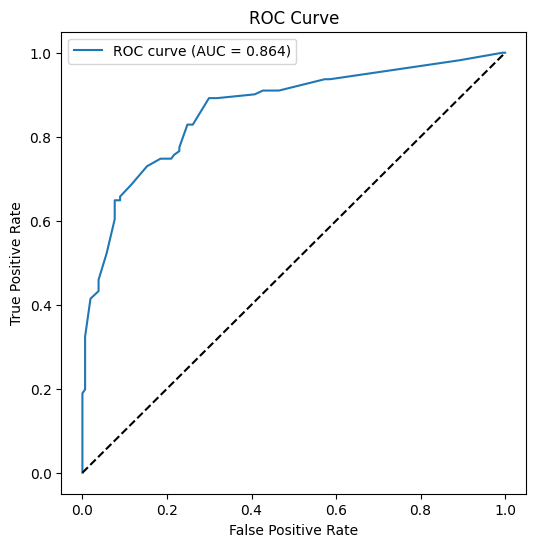

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

***La courbe ROC de notre modèle montre une très bonne capacité à discriminer les survivants et non-survivants du Titanic.
Avec un AUC = 0,864, il y a 86,4 % de chances que le modèle attribue une probabilité plus élevée à un survivant qu’à un non-survivant choisi au hasard.
Cela confirme que notre modèle optimisé est fiable et performant, même avant de fixer un seuil spécifique pour la classification.***

## 7. Déploiement du modèle

- **Sauvegarde du modèle**

In [74]:
import pickle


filename = "best_model.pkl"
with open(filename, "wb") as file:
    pickle.dump(best_model, file)

print("Modèle sauvegardé avec succès !")

Modèle sauvegardé avec succès !


- **Sauvegarde du seuil**

In [75]:
with open("threshold.pkl", "wb") as f:
    pickle.dump(best_t, f)

***Le modèle est déployé avec Flask en utilisant une prédiction probabiliste et un seuil optimisé. L’intercept est géré automatiquement par scikit-learn, ce qui garantit la cohérence entre l’entraînement et le déploiement.***

In [76]:
print(best_model.feature_names_in_)


['Sex_male' 'TrancheAge_[13,18]' 'TrancheAge_[19,35]' 'TrancheAge_[36,60]'
 'TrancheAge_[61,80]' 'Embarked_S' 'Pclass_2' 'Pclass_3']
